# **Initial Data Exploration & Cleaning**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

In [ ]:
df_sales= pd.read_csv("sales_data.csv")

# **Data Inspection:**

In [ ]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 544 entries, 0 to 543
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   date                              544 non-null    object 
 1   Medicine Name                     544 non-null    object 
 2   Medicine Type                     544 non-null    object 
 3   Medicine Category                 544 non-null    object 
 4   Pack Size                         544 non-null    int64  
 5   Sold Quantity                     544 non-null    int64  
 6   Selling Price                     544 non-null    int64  
 7   Total Sales Amount                544 non-null    int64  
 8   Received Medicine Price per pack  544 non-null    float64
 9   profit per sold pack              544 non-null    float64
 10  overall profit                    544 non-null    float64
dtypes: float64(3), int64(4), object(4)
memory usage: 46.9+ KB


In [ ]:
df_sales.describe()

,Pack Size,Sold Quantity,Selling Price,Total Sales Amount,Received Medicine Price per pack,profit per sold pack,overall profit
count,544.000000,544.000000,544.000000,544.000000,544.000000,544.000000,544.000000
mean,6.950368,1.397059,78.915441,104.126838,30.466783,48.448658,63.778125
std,4.595550,0.678851,55.875917,72.404255,24.476150,32.511615,42.425025
min,1.000000,1.000000,10.000000,10.000000,3.000000,7.000000,7.000000
25%,1.000000,1.000000,35.000000,60.000000,12.500000,23.000000,33.000000
50%,10.000000,1.000000,70.000000,90.000000,28.500000,41.500000,56.125000
75%,10.000000,2.000000,100.000000,120.000000,34.500000,61.250000,75.500000
max,15.000000,3.000000,400.000000,400.000000,160.000000,240.000000,240.000000


In [ ]:
df_sales.describe(include='object')

,date,Medicine Name,Medicine Type,Medicine Category
count,544,544,544,544
unique,92,69,13,3
top,01/05/2025,cheston-cold,tablet,generic
freq,9,40,259,408


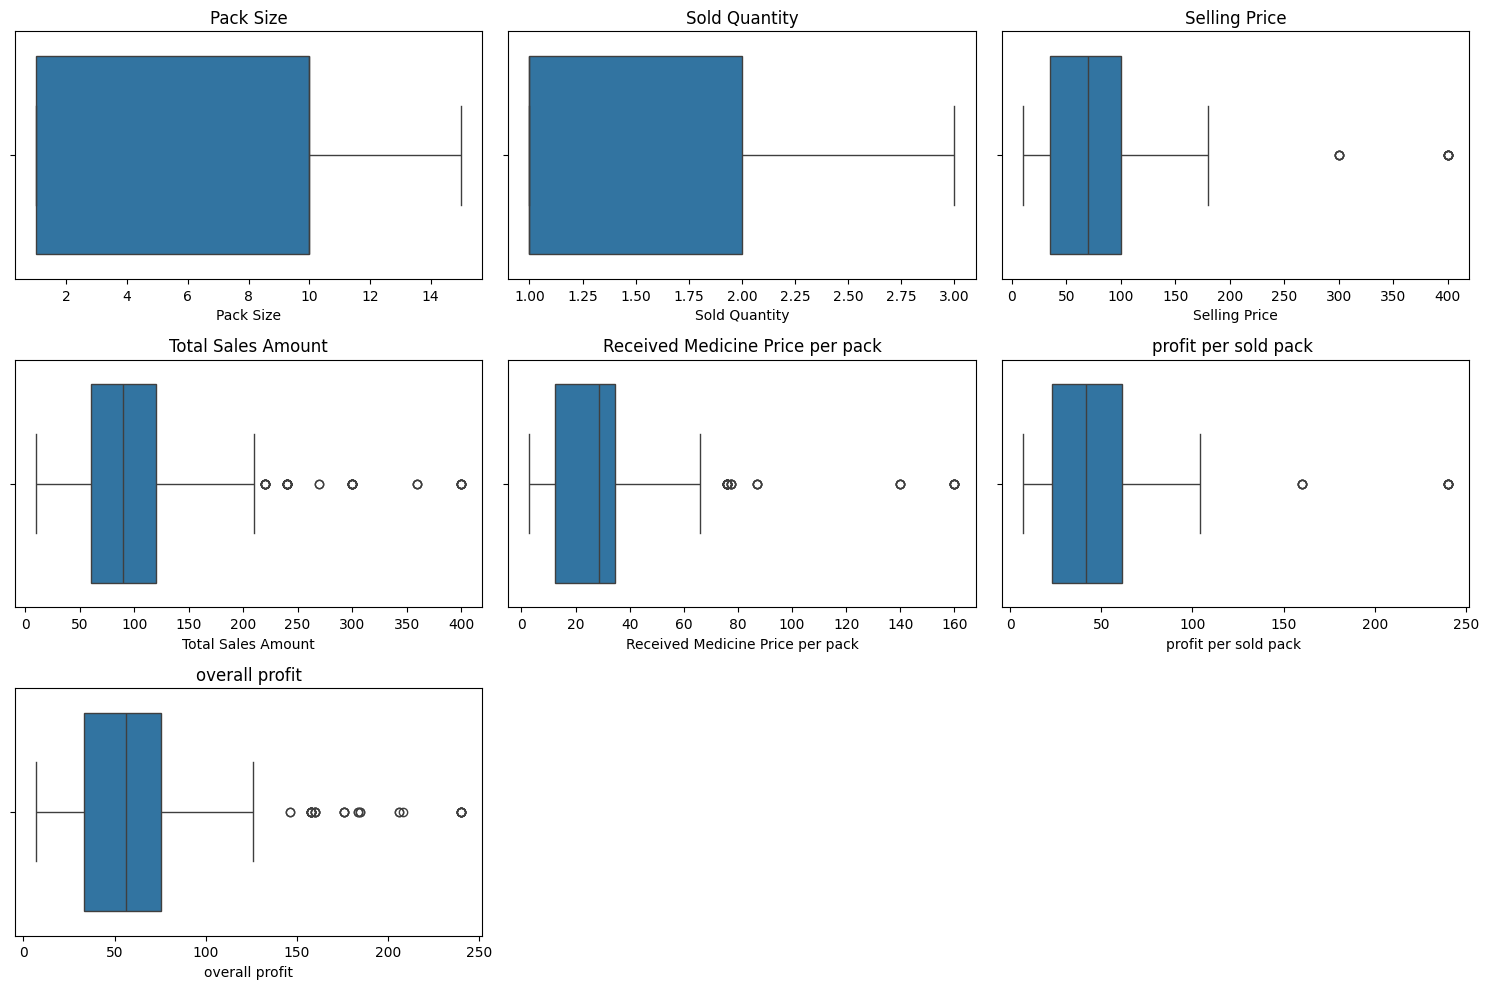

In [ ]:
# Select only numeric columns for the box plot
numeric_cols = df_sales.select_dtypes(include=np.number).columns

# Create box plots for each numeric column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
  plt.subplot(len(numeric_cols) // 3 + 1, 3, i + 1)
  sns.boxplot(x=df_sales[col])
  plt.title(col)

plt.tight_layout()
plt.show()

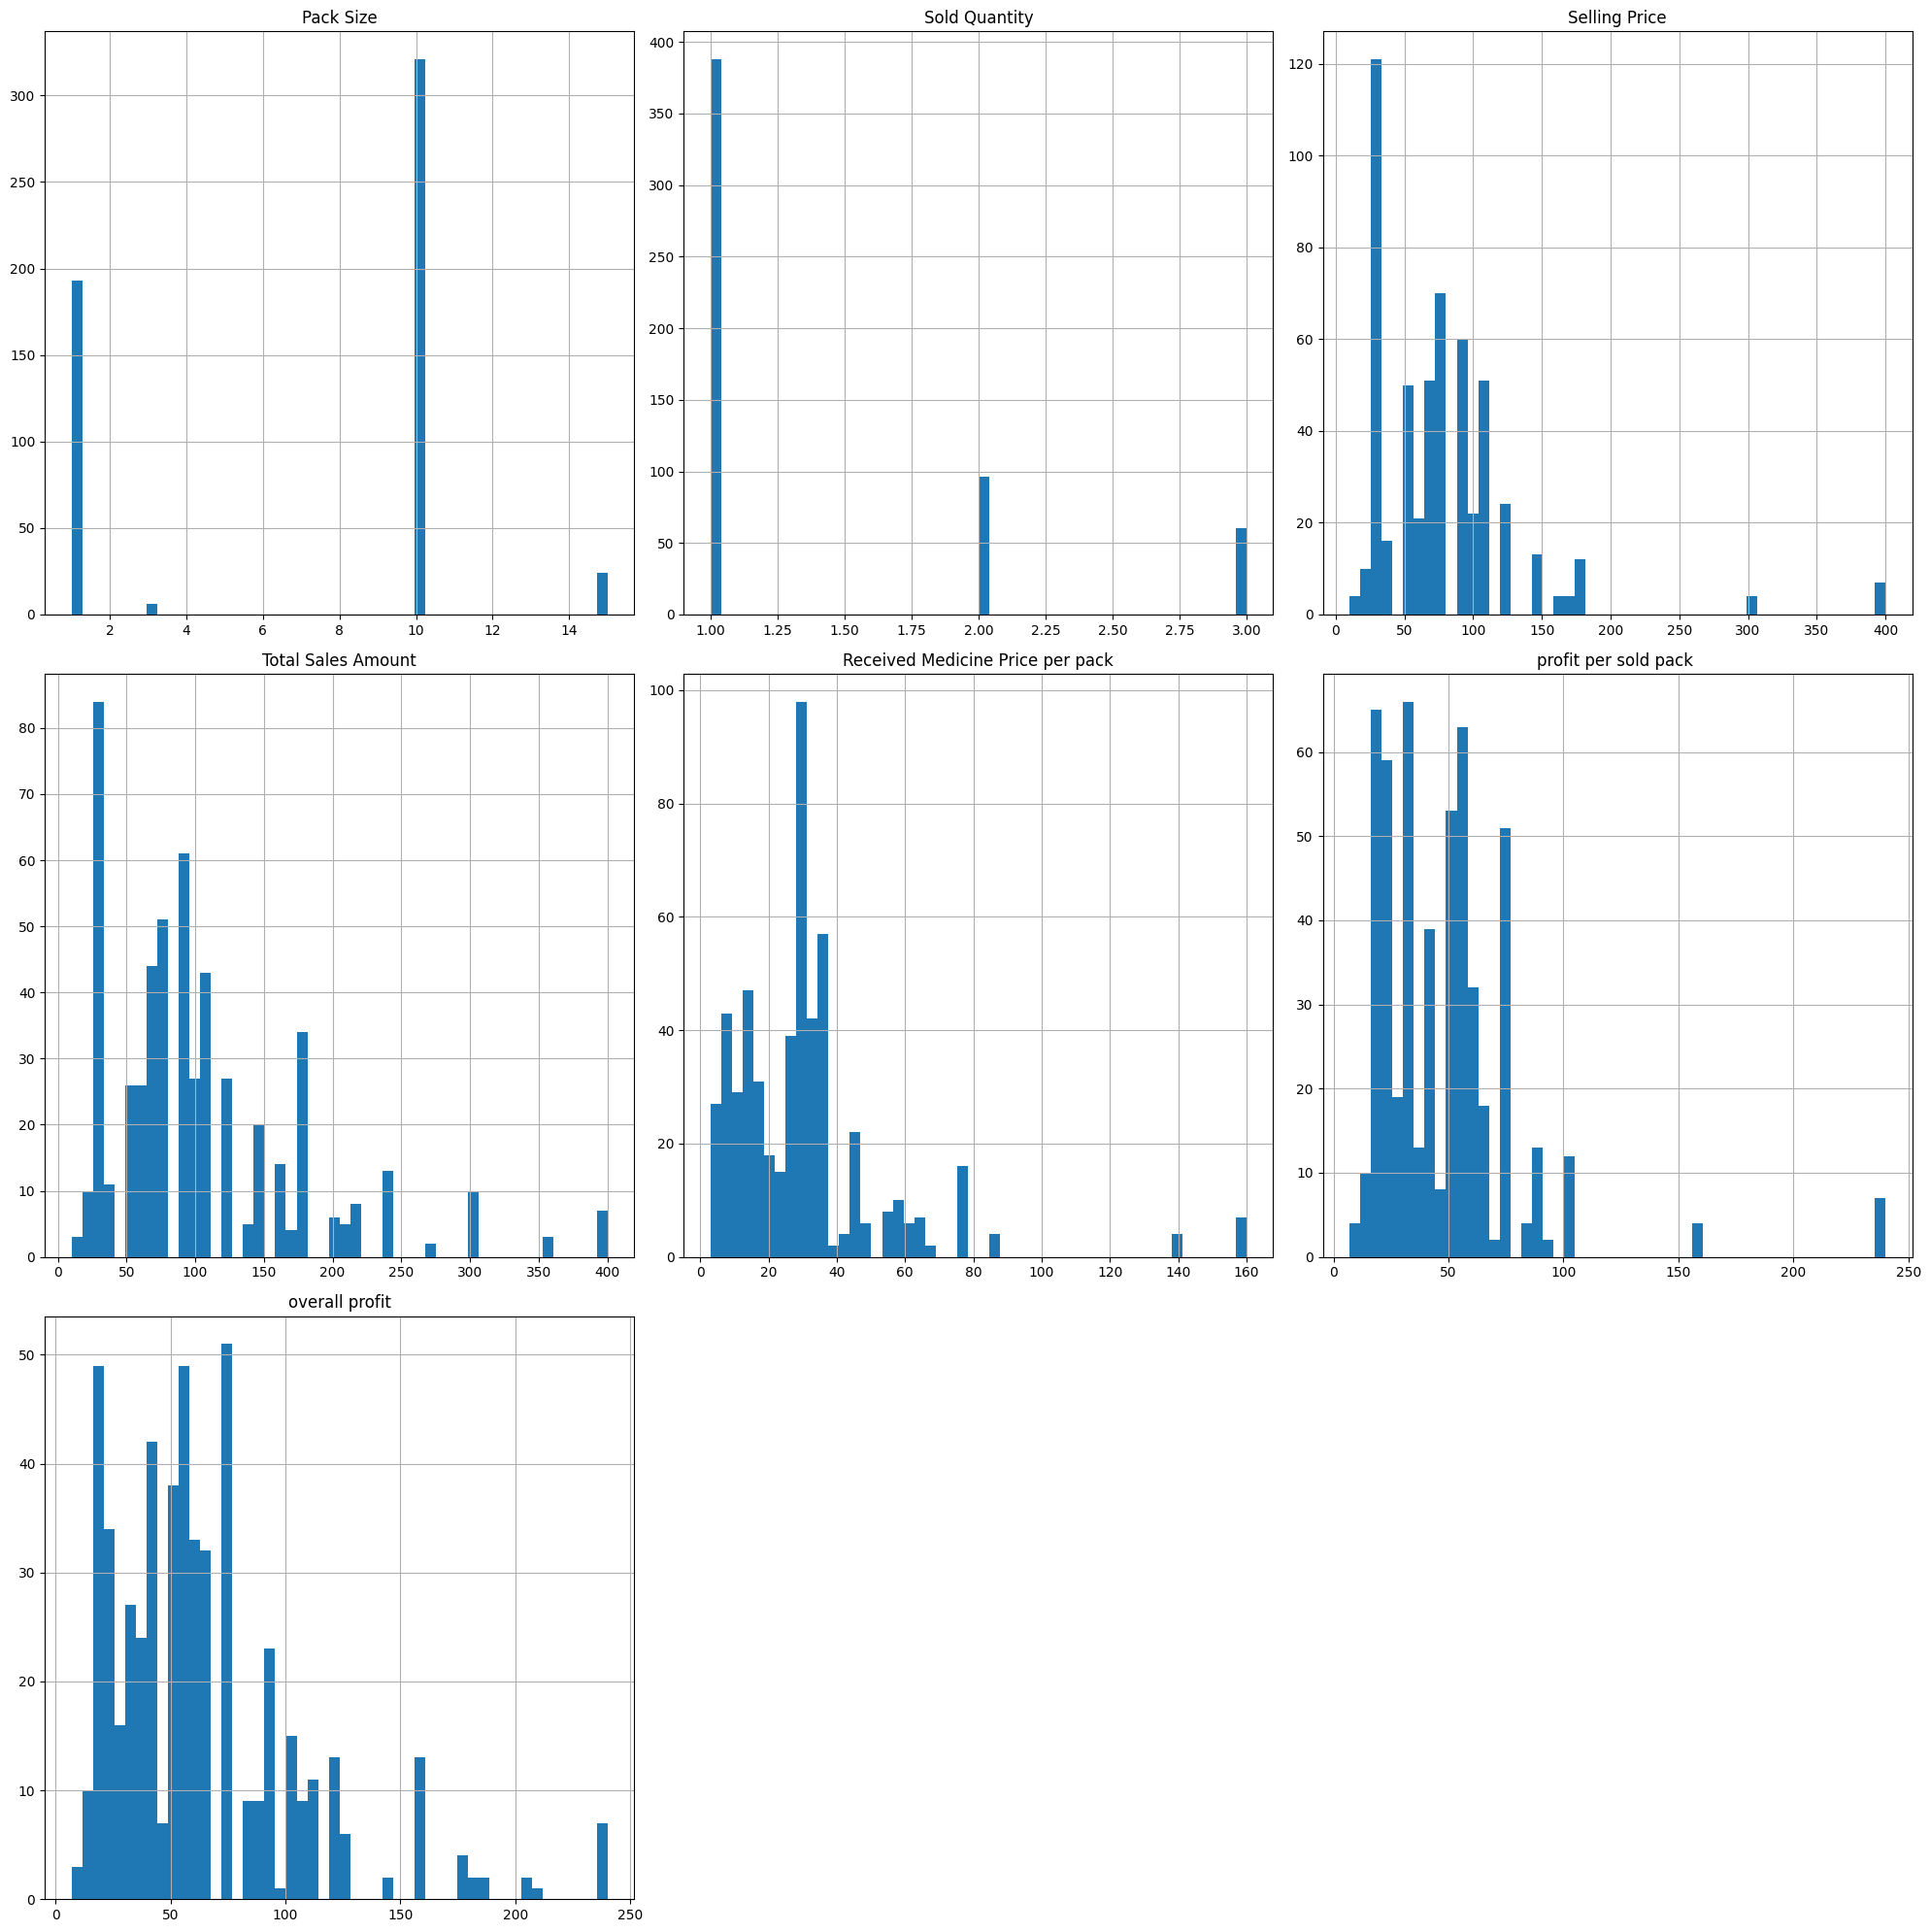

In [ ]:
df_sales.hist(bins=50, figsize=(20, 20))
plt.tight_layout()
plt.show()

# **Feature Analysis:**

In [ ]:
num_f = df_sales.select_dtypes(include=['number']).columns
corr_matrix = df_sales[num_f].corr()
corr_matrix['Total Sales Amount']

,Total Sales Amount
Pack Size,0.041795
Sold Quantity,0.448816
Selling Price,0.761638
Total Sales Amount,1.000000
Received Medicine Price per pack,0.758991
profit per sold pack,0.737585
overall profit,0.982432


<Axes: >

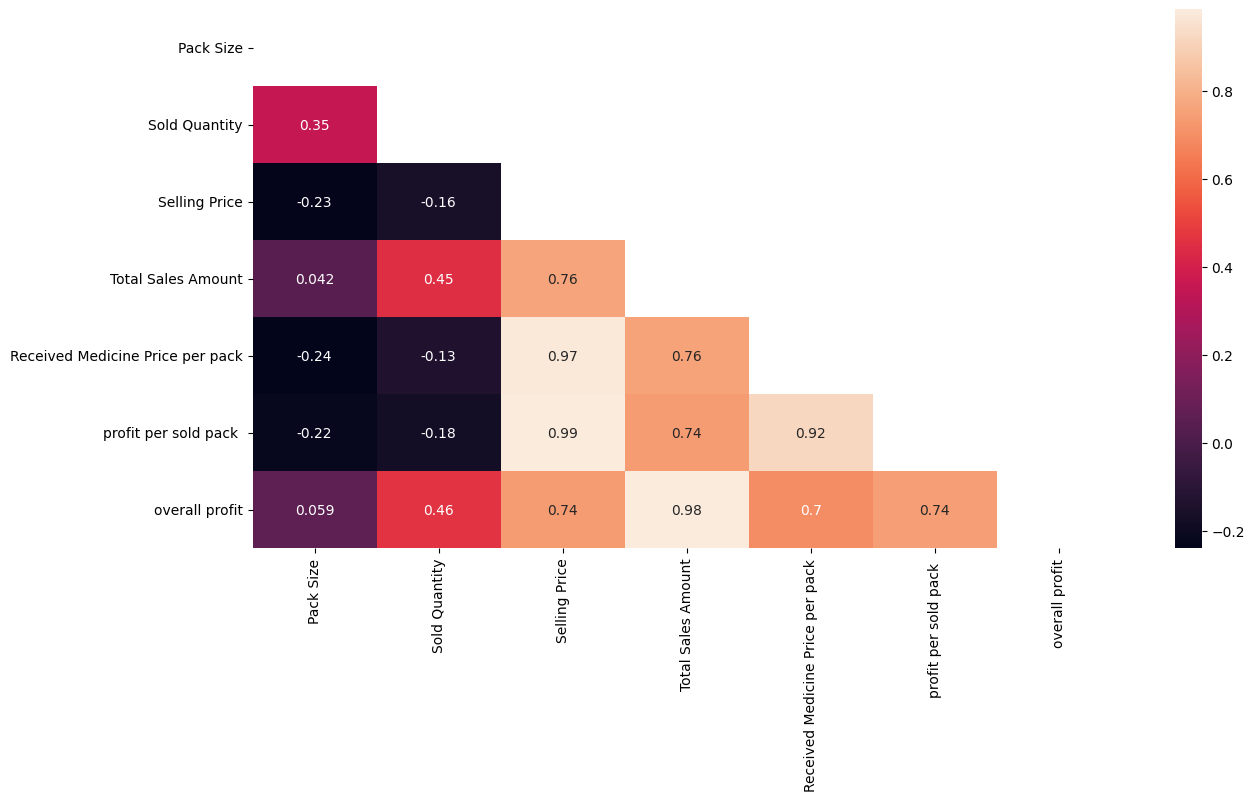

In [ ]:
plt.figure(figsize=(14,7))
mask = np.triu(corr_matrix)
sns.heatmap(corr_matrix, annot=True, mask= mask)

# **Data Preprocessing:**

In [ ]:
import pandas as pd

# Make a copy to preserve the original
df_clean = df_sales.copy()

# Select only numeric columns
numeric_cols = df_clean.select_dtypes(include=['number']).columns

# Loop through each numeric column
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out rows outside the bounds
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

# Check the shape before and after
print("Original shape:", df_sales.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (544, 11)
Cleaned shape: (490, 11)


In [ ]:
df_sales.isnull().sum()[df_clean.isnull().sum() > 0]

,0


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 490 entries, 0 to 543
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   date                              490 non-null    object 
 1   Medicine Name                     490 non-null    object 
 2   Medicine Type                     490 non-null    object 
 3   Medicine Category                 490 non-null    object 
 4   Pack Size                         490 non-null    int64  
 5   Sold Quantity                     490 non-null    int64  
 6   Selling Price                     490 non-null    int64  
 7   Total Sales Amount                490 non-null    int64  
 8   Received Medicine Price per pack  490 non-null    float64
 9   profit per sold pack              490 non-null    float64
 10  overall profit                    490 non-null    float64
dtypes: float64(3), int64(4), object(4)
memory usage: 45.9+ KB


In [ ]:
df_clean.describe(include='object')

,date,Medicine Name,Medicine Type,Medicine Category
count,490,490,490,490
unique,92,61,12,3
top,01/05/2025,cheston-cold,tablet,generic
freq,9,40,252,381


In [ ]:
df_clean['date'] = pd.to_datetime(df_clean['date'], format='%m/%d/%Y', errors='coerce')

# **Sales Performance:**

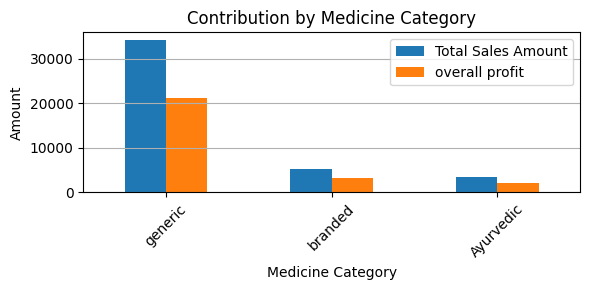

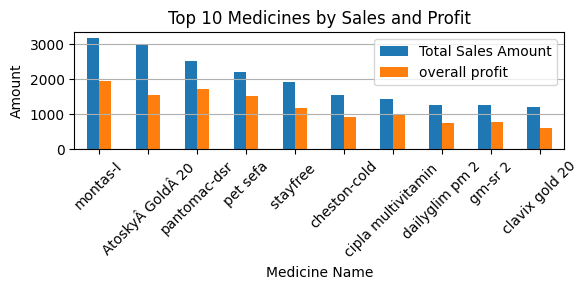

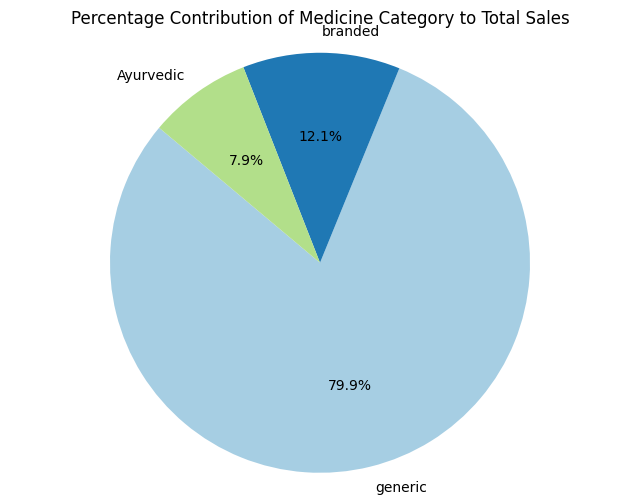

In [ ]:
# Group by Medicine Category
category_sales = df_clean.groupby('Medicine Category')[['Total Sales Amount', 'overall profit']].sum().sort_values(by='Total Sales Amount', ascending=False)

# Plot
category_sales.plot(kind='bar', figsize=(6, 3), title='Contribution by Medicine Category')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
# Top 10 Medicines by Sales
top_medicines = df_clean.groupby('Medicine Name')[['Total Sales Amount', 'overall profit']].sum().sort_values(by='Total Sales Amount', ascending=False).head(10)

# Plot
top_medicines.plot(kind='bar', figsize=(6, 3), title='Top 10 Medicines by Sales and Profit')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
import matplotlib.pyplot as plt

# Calculate percentage contribution
category_percent = df_clean.groupby('Medicine Category')['Total Sales Amount'].sum()
category_percent = category_percent.sort_values(ascending=False)
category_percent_pct = 100 * category_percent / category_percent.sum()

# Pie chart
plt.figure(figsize=(8, 6))
plt.pie(category_percent_pct, labels=category_percent_pct.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Percentage Contribution of Medicine Category to Total Sales')
plt.axis('equal')
plt.show()

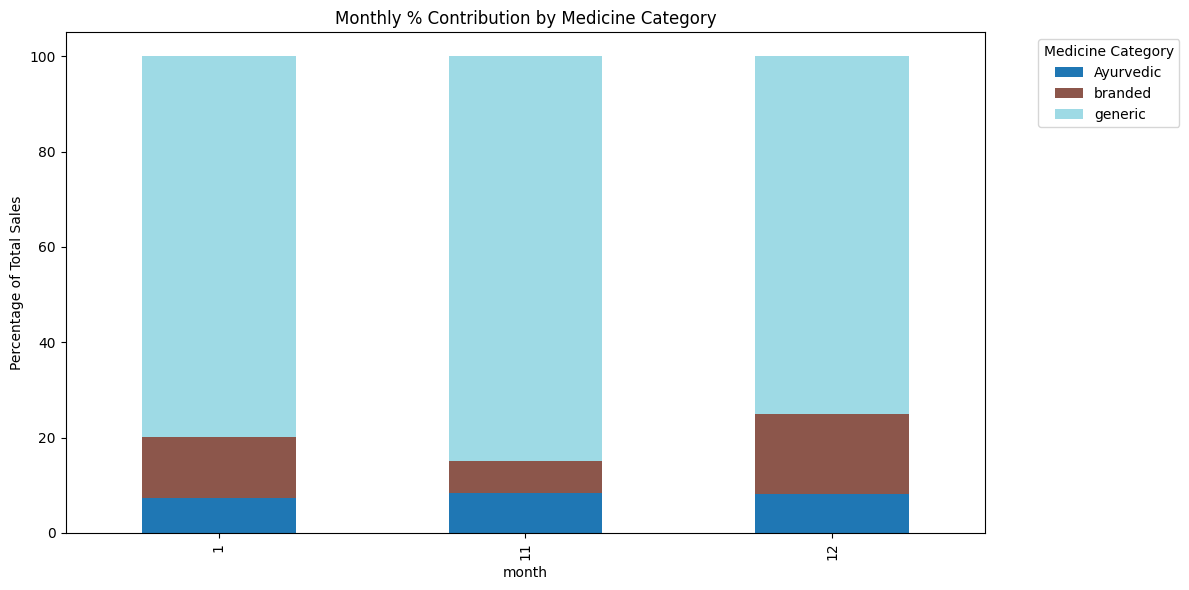

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure date column is datetime and extract month
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean['month'] = df_clean['date'].dt.month

# Group by month and medicine category, summing sales
monthly_category = df_clean.groupby(['month', 'Medicine Category'])['Total Sales Amount'].sum().unstack(fill_value=0)

# Convert to percentage
monthly_category_pct = monthly_category.div(monthly_category.sum(axis=1), axis=0) * 100

# Plot
monthly_category_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.ylabel('Percentage of Total Sales')
plt.title('Monthly % Contribution by Medicine Category')
plt.legend(title='Medicine Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# **Sales Forecasting Models**

In [ ]:
# Ensure 'date' is datetime and sorted
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean.sort_values('date', inplace=True)

# Aggregate sales by date
df_ts = df_clean.groupby('date')['Total Sales Amount'].sum().reset_index()
df_ts.set_index('date', inplace=True)

y = df_ts['Total Sales Amount']

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Feature engineering
df_xgb = df_ts.copy()
df_xgb['year'] = df_xgb.index.year
df_xgb['month'] = df_xgb.index.month
df_xgb['day'] = df_xgb.index.day
df_xgb['dayofweek'] = df_xgb.index.dayofweek
df_xgb['lag_1'] = df_xgb['Total Sales Amount'].shift(1)
df_xgb['rolling_3'] = df_xgb['Total Sales Amount'].rolling(3).mean()
df_xgb.dropna(inplace=True)

X = df_xgb[['year', 'month', 'day', 'dayofweek', 'lag_1', 'rolling_3']]
y = df_xgb['Total Sales Amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1)
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print(f"XGBoost MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}")
print(f"R² Score: {r2:.4f}")

XGBoost MAE: 71.55, RMSE: 99.62
R² Score: 0.2307


In [ ]:
residuals_xgb = y_test - y_pred_xgb

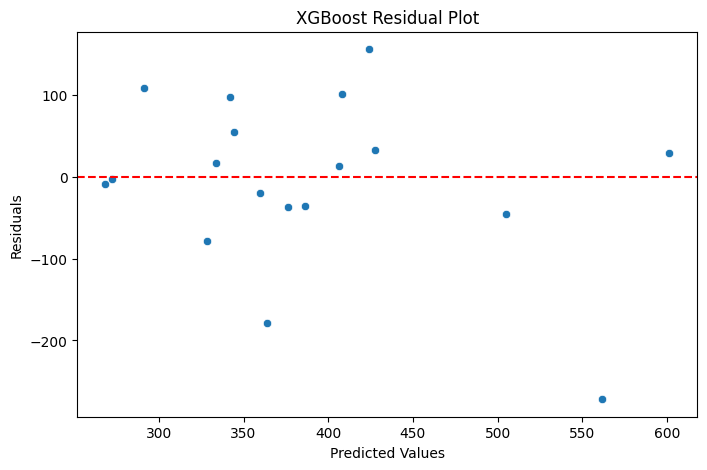

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_xgb, y=residuals_xgb)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('XGBoost Residual Plot')
plt.show()


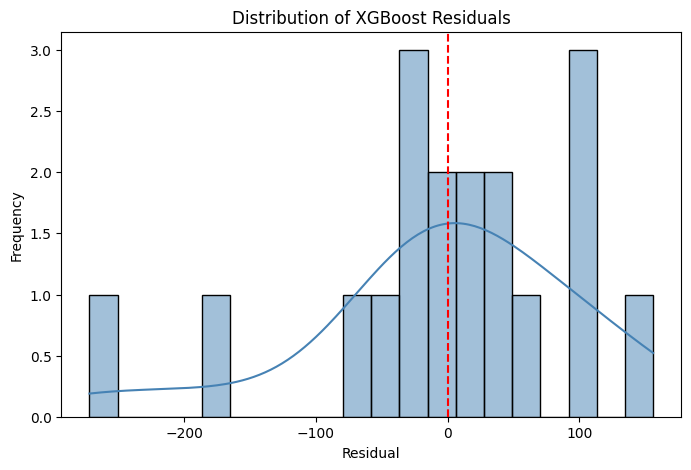

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals_xgb, kde=True, bins=20, color='steelblue')
plt.title('Distribution of XGBoost Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

In [ ]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

df_clean['Year'] = df_clean['date'].dt.year
df_clean['Month'] = df_clean['date'].dt.month
df_clean['Day'] = df_clean['date'].dt.day
df_clean['DayOfWeek'] = df_clean['date'].dt.dayofweek

# Drop the original 'date' column
df_clean.drop(columns=['date'], inplace=True)

# Step 2: Drop NA values after processing
df_clean.dropna(inplace=True)

# Step 3: Separate target and features
y = df_clean['Total Sales Amount']
X = df_clean.drop(columns=['Total Sales Amount'])

# Step 4: Re-identify feature types
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Step 5: Preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Step 6: Pipeline and model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb)
])

# Step 7: Hyperparameter tuning
param_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [3, 5],
    'regressor__learning_rate': [0.01, 0.1],
    'regressor__subsample': [0.8, 1.0],
    'regressor__colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    error_score='raise'
)

# Step 8: Fit and get results
grid_search.fit(X, y)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best parameters:", best_params)


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'regressor__colsample_bytree': 0.8, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__n_estimators': 100, 'regressor__subsample': 0.8}


✅ XGBoost Model Evaluation:
MAE:  16.87
RMSE: 23.94
R²:   0.7403


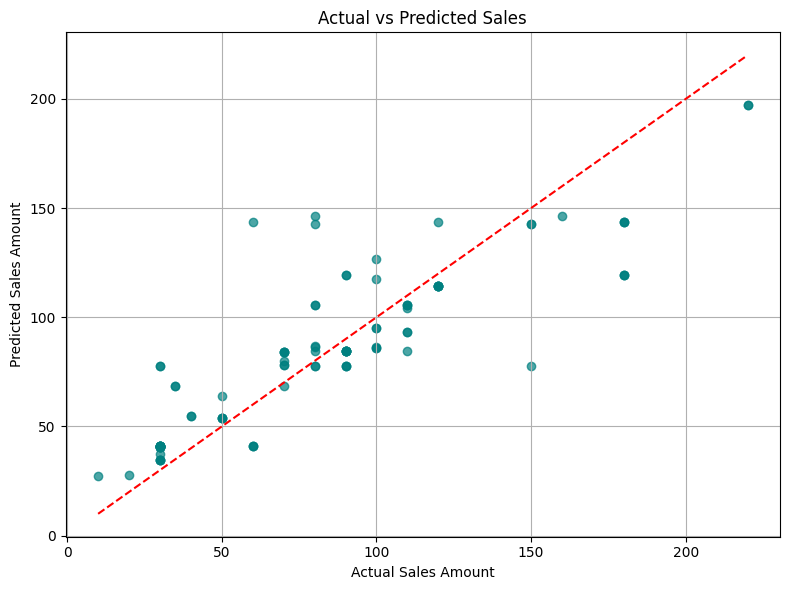

In [ ]:
#2. Define features and target
# ----------------------------------
y = df_clean['Total Sales Amount']
X = df_clean.drop(columns=['Total Sales Amount'])

# ----------------------------------
# 3. Train/test split
# ----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------------
# 4. Identify column types
# ----------------------------------
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# ----------------------------------
# 5. Create preprocessing pipeline
# ----------------------------------
preprocessor = ColumnTransformer([

    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

# ----------------------------------
# 6. Define XGBRegressor with best params
# ----------------------------------
xgb = XGBRegressor(
    objective='reg:squarederror',
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    subsample=0.8,
    random_state=42
)

# ----------------------------------
# 7. Build and fit pipeline
# ----------------------------------
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', xgb)
])

pipeline.fit(X_train, y_train)

# ----------------------------------
# 8. Evaluate model
# ----------------------------------
y_pred_x = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_x)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_x))
r2 = r2_score(y_test, y_pred_x)

print("✅ XGBoost Model Evaluation:")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

# ----------------------------------
# 9. Optional: Plot predicted vs actual
# ----------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_x, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Sales Amount')
plt.ylabel('Predicted Sales Amount')
plt.title('Actual vs Predicted Sales')
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2412424152.py:24: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


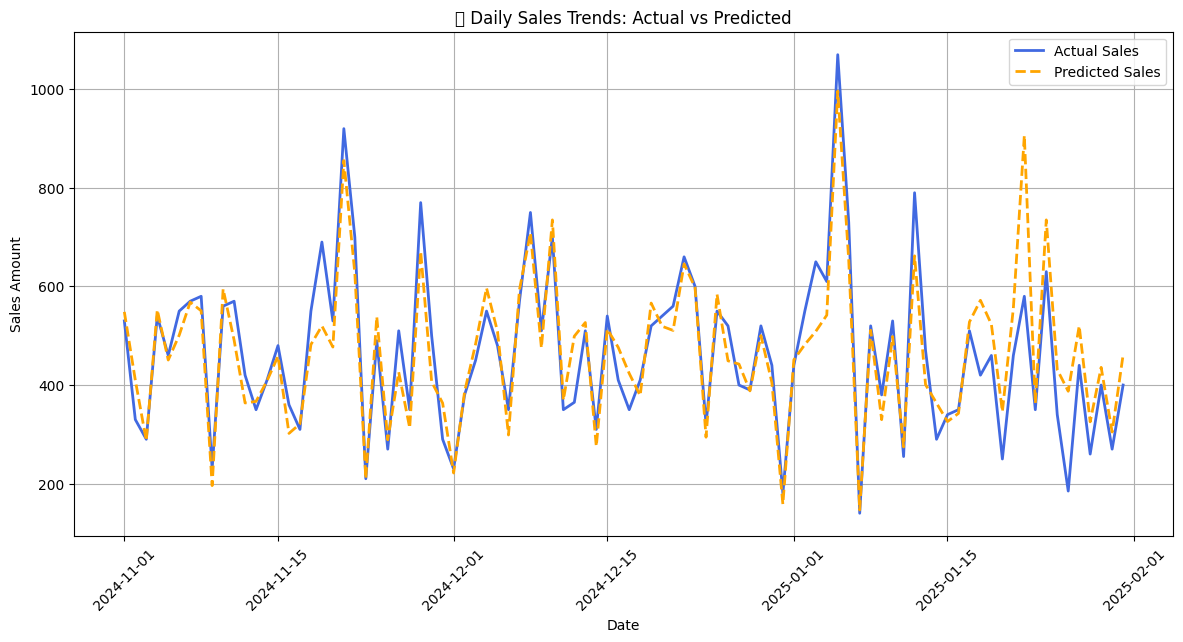

In [ ]:
#Predict on the entire dataset
df_clean['Predicted Sales Amount'] = pipeline.predict(X)
# Group by date and calculate actual vs predicted
# ----------------------------------
# Use the engineered date features for grouping
daily_trends = df_clean.groupby(['Year', 'Month', 'Day'])[['Total Sales Amount', 'Predicted Sales Amount']].sum().reset_index()

# Create a date column from the engineered features for plotting
daily_trends['date'] = pd.to_datetime(daily_trends[['Year', 'Month', 'Day']])


# ----------------------------------
# Plot daily actual vs predicted sales
# ----------------------------------
plt.figure(figsize=(12, 6))
plt.plot(daily_trends['date'], daily_trends['Total Sales Amount'], label='Actual Sales', color='royalblue', linewidth=2)
plt.plot(daily_trends['date'], daily_trends['Predicted Sales Amount'], label='Predicted Sales', color='orange', linewidth=2, linestyle='--')

plt.title('📅 Daily Sales Trends: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


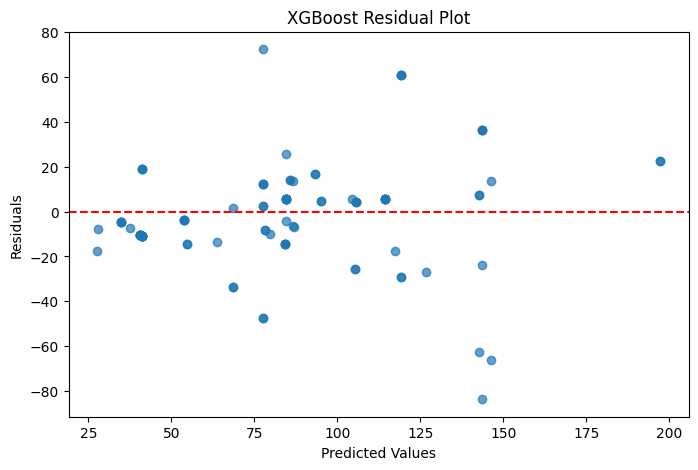

In [ ]:
# Residual plot
residuals = y_test - y_pred_x
plt.figure(figsize=(8,5))
plt.scatter(y_pred_x, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('XGBoost Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

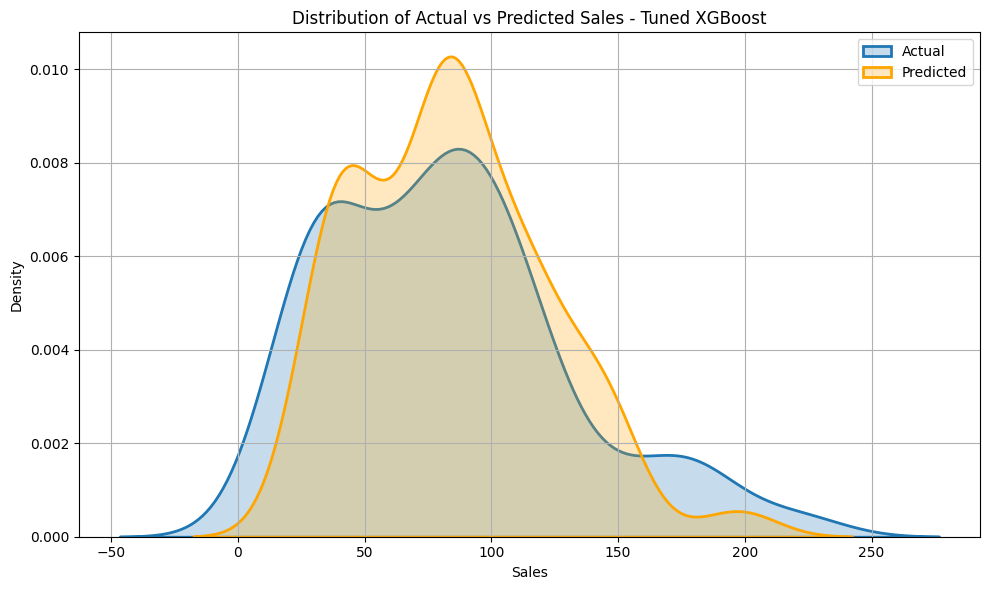

In [ ]:
# Plot distribution of actual vs predicted values for the tuned XGBoost model
plt.figure(figsize=(10, 6))
sns.kdeplot(y_test, label='Actual', fill=True, linewidth=2)
sns.kdeplot(y_pred_x, label='Predicted', fill=True, linewidth=2, color='orange')
plt.title('Distribution of Actual vs Predicted Sales - Tuned XGBoost')
plt.xlabel('Sales')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


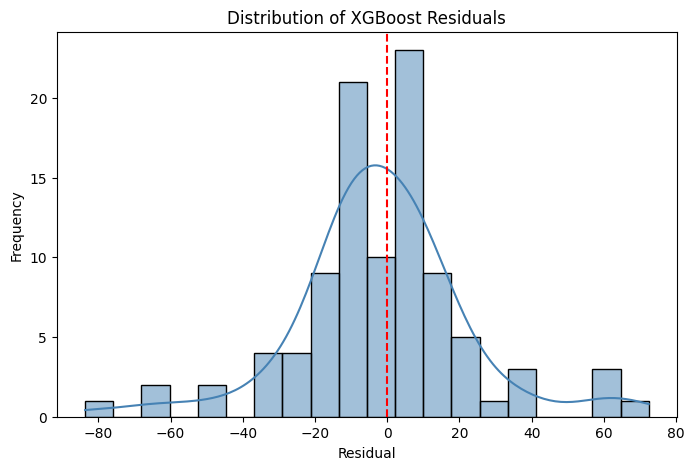

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=20, color='steelblue')
plt.title('Distribution of XGBoost Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

In [ ]:
df_inventory= pd.read_csv("inventory_data.csv")
df_inventory.head()

,Date,Medicine name,Opening stock,New stock,Stock out,Closing stock,Expiry date
0,11/01/2024,acyclosure p,11,20.0,NaN,31,07/01/2025
1,12/01/2024,acyclosure p,31,0.0,11.0,20,NaN
2,01/01/2025,acyclosure p,20,0.0,9.0,11,NaN
3,01/31/2025,acyclosure p,11,20.0,9.0,22,01/15/2026
4,11/01/2024,amlokind h,15,0.0,NaN,15,01/15/2026


# **Inventory Analysis**

In [ ]:
df_inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           244 non-null    object 
 1   Medicine name  244 non-null    object 
 2   Opening stock  244 non-null    int64  
 3   New stock      243 non-null    float64
 4   Stock out      174 non-null    float64
 5   Closing stock  244 non-null    int64  
 6   Expiry date    108 non-null    object 
dtypes: float64(2), int64(2), object(3)
memory usage: 13.5+ KB


# **ABC Analysis**

,Medicine name,Total Value,Cumulative %,Category
0,montas-l,453750.0,13.648423,A
1,pantomac-dsr,370800.0,24.801778,A
2,remium gold,182400.0,30.288219,A
3,pet sefa,162800.0,35.185107,A
4,cheston-cold,160800.0,40.021837,A
5,montecip LC,159840.0,44.829692,A
6,omniclav 625,114450.0,48.272253,A
7,gm-sr 2,110000.0,51.580961,A
8,cuflift ls,108000.0,54.829511,A
9,cipvildin-m,101400.0,57.879539,A


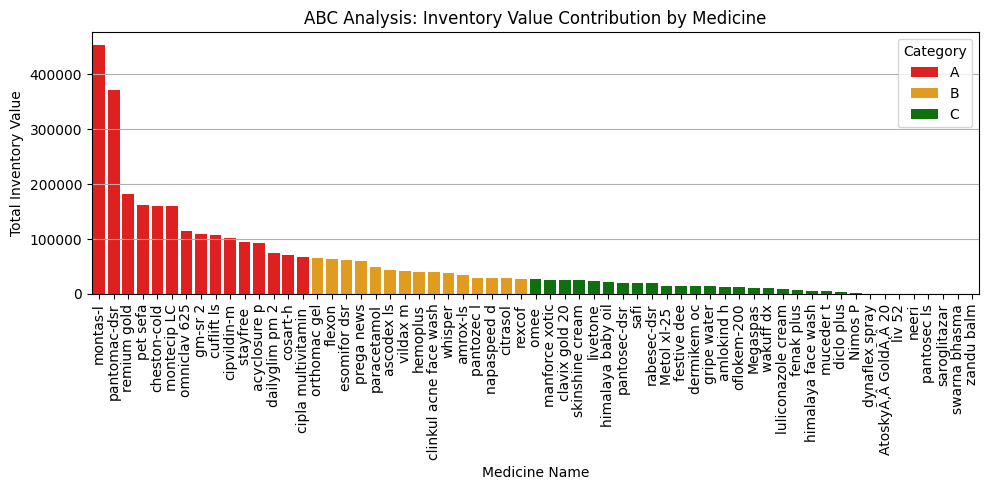

In [ ]:
# Merge df_inventory with df_clean to get Selling Price
df_abc = df_inventory.merge(
    df_clean[['Medicine Name', 'Selling Price']],
    left_on='Medicine name',
    right_on='Medicine Name',
    how='left'
)

# Calculate Total Value per record
df_abc['New stock'] = df_abc['New stock'].fillna(0)
df_abc['Closing stock'] = df_abc['Closing stock'].fillna(0)
df_abc['Total Value'] = (df_abc['Closing stock'] + df_abc['New stock']) * df_abc['Selling Price']

# Aggregate total value per medicine
abc_summary = df_abc.groupby('Medicine name')['Total Value'].sum().reset_index()

# Sort descending by total value
abc_summary = abc_summary.sort_values(by='Total Value', ascending=False).reset_index(drop=True)

# Compute cumulative percentage
abc_summary['Cumulative %'] = 100 * abc_summary['Total Value'].cumsum() / abc_summary['Total Value'].sum()

# ABC categorization function
def classify_abc(cum_pct):
    if cum_pct <= 70:
        return 'A'
    elif cum_pct <= 90:
        return 'B'
    else:
        return 'C'

abc_summary['Category'] = abc_summary['Cumulative %'].apply(classify_abc)

# Show summary table
display(abc_summary.head(10))

# 📈 Visualization: Stacked Bar with A/B/C categories
plt.figure(figsize=(10, 5))
sns.barplot(x='Medicine name', y='Total Value', hue='Category', data=abc_summary,
            palette={'A': 'red', 'B': 'orange', 'C': 'green'})

plt.xticks(rotation=90)
plt.title('ABC Analysis: Inventory Value Contribution by Medicine')
plt.xlabel('Medicine Name')
plt.ylabel('Total Inventory Value')
plt.legend(title='Category')
plt.tight_layout()
plt.grid(axis='y')
plt.show()


# **Waste & Stock-Outs:**

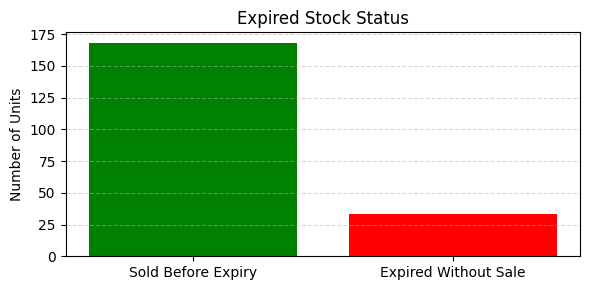

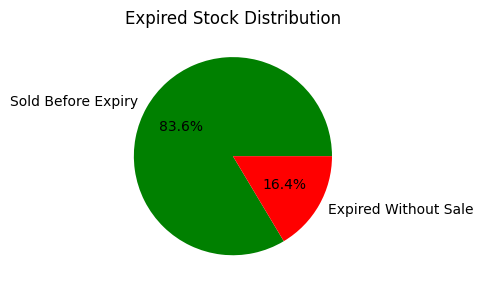

In [ ]:
# Optional: Normalize column names for consistency
df_sales.columns = df_sales.columns.str.strip().str.lower()
df_inventory.columns = df_inventory.columns.str.strip().str.lower()

# Convert expiry date to datetime
df_inventory['expiry date'] = pd.to_datetime(df_inventory['expiry date'], errors='coerce')

# Filter expired inventory

today = pd.to_datetime('2025-06-17')
expired_inventory = df_inventory[df_inventory['expiry date'] < today]

# Merge sales and expired inventory on medicine name
expired_sold = pd.merge(df_sales, expired_inventory, how='inner', on='medicine name')

# Calculate sold quantity of expired medicines
expired_units_sold = expired_sold['sold quantity'].sum()

# Calculate total expired stock from inventory
total_expired_units = expired_inventory['closing stock'].sum()

# Calculate expired units that were not sold
expired_units_unsold = total_expired_units - expired_units_sold
expired_units_unsold = max(0, expired_units_unsold)  # Ensure non-negative

# Create DataFrame for visualization
expired_data = pd.DataFrame({
    'Status': ['Sold Before Expiry', 'Expired Without Sale'],
    'Units': [expired_units_sold, expired_units_unsold]
})

# Bar Chart
plt.figure(figsize=(6, 3))
plt.bar(expired_data['Status'], expired_data['Units'], color=['green', 'red'])
plt.title('Expired Stock Status')
plt.ylabel('Number of Units')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Pie Chart
plt.figure(figsize=(6, 3))
plt.pie(expired_data['Units'], labels=expired_data['Status'], autopct='%1.1f%%', colors=['green', 'red'])
plt.title('Expired Stock Distribution')
plt.tight_layout()
plt.show()


In [ ]:
# Ensure 'date' columns are in datetime format
df_sales['date'] = pd.to_datetime(df_sales['date'], errors='coerce')
df_inventory['date'] = pd.to_datetime(df_inventory['date'], errors='coerce')

# Aggregate sold quantity by medicine name
sales_agg = df_sales.groupby('medicine name')['sold quantity'].sum().reset_index()
sales_agg.columns = ['Medicine Name', 'Total Sold Quantity']

# Aggregate new stock by medicine name
stock_agg = df_inventory.groupby('medicine name')['new stock'].sum().reset_index()
stock_agg.columns = ['Medicine Name', 'Total New Stock']

# Merge sales and stock
stock_vs_sales = pd.merge(stock_agg, sales_agg, on='Medicine Name', how='inner')

# Calculate surplus or deficit
stock_vs_sales['Surplus'] = stock_vs_sales['Total New Stock'] - stock_vs_sales['Total Sold Quantity']

# Classify as Overstocked or Understocked
stock_vs_sales['Stock Condition'] = stock_vs_sales['Surplus'].apply(lambda x: 'Overstocked' if x > 0 else 'Understocked')


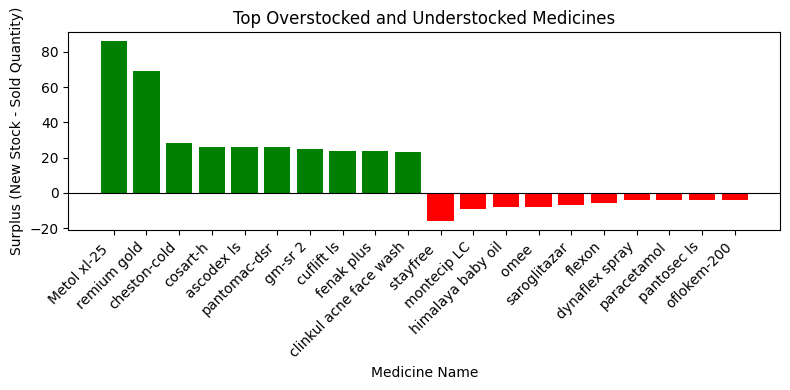

In [ ]:
# Sort and select top 10 overstocked and understocked
top_overstocked = stock_vs_sales.sort_values(by='Surplus', ascending=False).head(10)
top_understocked = stock_vs_sales.sort_values(by='Surplus').head(10)

# Combine for plotting
top_combined = pd.concat([top_overstocked, top_understocked])

# Plot
plt.figure(figsize=(8, 4))
colors = top_combined['Stock Condition'].map({'Overstocked': 'green', 'Understocked': 'red'})
bars = plt.bar(top_combined['Medicine Name'], top_combined['Surplus'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Medicine Name')
plt.ylabel('Surplus (New Stock - Sold Quantity)')
plt.title('Top Overstocked and Understocked Medicines')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **DEA (Data Envelopment Analysis)**

In [ ]:
%pip install pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 81.1 MB/s eta 0:00:00


/tmp/ipython-input-1522361352.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped.sort_values('efficiency_score', ascending=False),


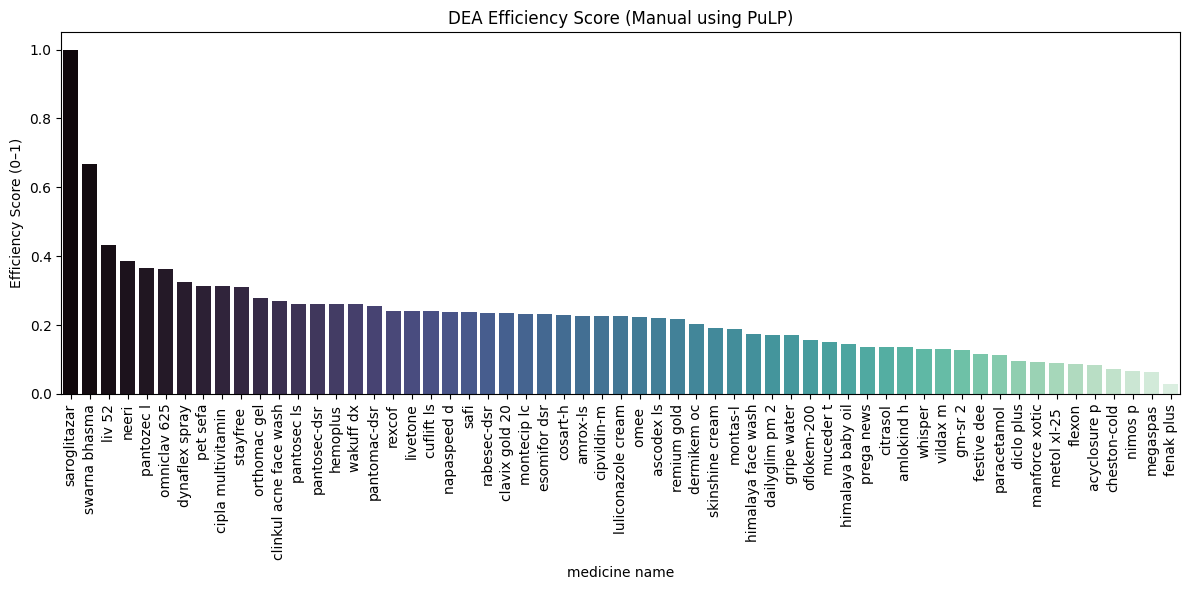

In [ ]:
import pulp
# Step 1: Prepare dataset
df_sales['medicine name'] = df_sales['medicine name'].str.lower()
df_inventory['medicine name'] = df_inventory['medicine name'].str.lower()

df = pd.merge(df_sales, df_inventory, on='medicine name', how='inner')

# Aggregate per medicine
df_grouped = df.groupby('medicine name').agg({
    'sold quantity': 'sum',
    'overall profit': 'sum',
    'new stock': 'sum'
}).reset_index()

df_grouped.rename(columns={
    'sold quantity': 'input1_sold_qty',
    'new stock': 'input2_stock',
    'overall profit': 'output1_profit'
}, inplace=True)

# Step 2: DEA-like Efficiency Score Calculation
scores = []
for i, row in df_grouped.iterrows():
    # Create LP problem
    prob = pulp.LpProblem("DEA", pulp.LpMaximize)

    # Weights for outputs and inputs
    u = pulp.LpVariable("u", lowBound=0)  # output weight
    v1 = pulp.LpVariable("v1", lowBound=0)  # input1 weight
    v2 = pulp.LpVariable("v2", lowBound=0)  # input2 weight

    # Objective: Maximize efficiency for DMU_i
    prob += u * row['output1_profit'], "Efficiency"

    # Constraints: Efficiency of all DMUs must be ≤ 1
    for j, peer in df_grouped.iterrows():
        prob += (
            u * peer['output1_profit']
            - v1 * peer['input1_sold_qty']
            - v2 * peer['input2_stock']
            <= 0
        )

    # Normalize denominator for DMU_i
    prob += (
        v1 * row['input1_sold_qty'] + v2 * row['input2_stock']
        == 1
    )

    prob.solve()

    if pulp.LpStatus[prob.status] == 'Optimal':
        efficiency = pulp.value(u * row['output1_profit'])
    else:
        efficiency = np.nan
    scores.append(efficiency)

# Step 3: Visualize Efficiency Scores
df_grouped['efficiency_score'] = scores

plt.figure(figsize=(12, 6))
sns.barplot(data=df_grouped.sort_values('efficiency_score', ascending=False),
            x='medicine name', y='efficiency_score', palette='mako')
plt.xticks(rotation=90)
plt.title("DEA Efficiency Score (Manual using PuLP)")
plt.ylabel("Efficiency Score (0–1)")
plt.tight_layout()
plt.show()

/tmp/ipython-input-4137824967.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20, x='medicine name', y='efficiency_score', palette='viridis')


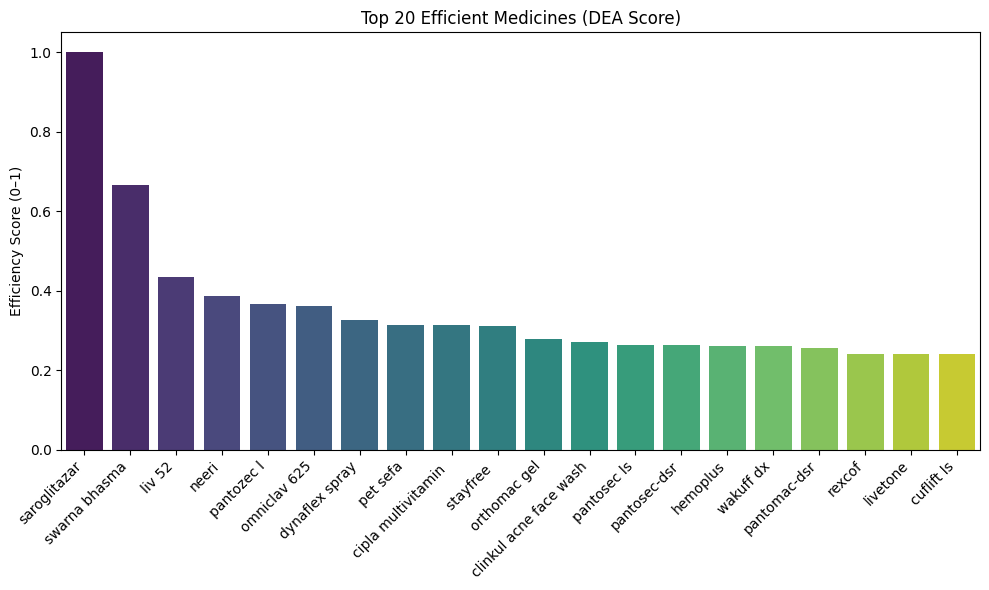

In [ ]:
# Top 20 most efficient medicines
top_20 = df_grouped.sort_values('efficiency_score', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_20, x='medicine name', y='efficiency_score', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title("Top 20 Efficient Medicines (DEA Score)")
plt.ylabel("Efficiency Score (0–1)")
plt.xlabel("")
plt.tight_layout()
plt.show()

/tmp/ipython-input-3696495065.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_grouped, x='eff_bin', palette='coolwarm')


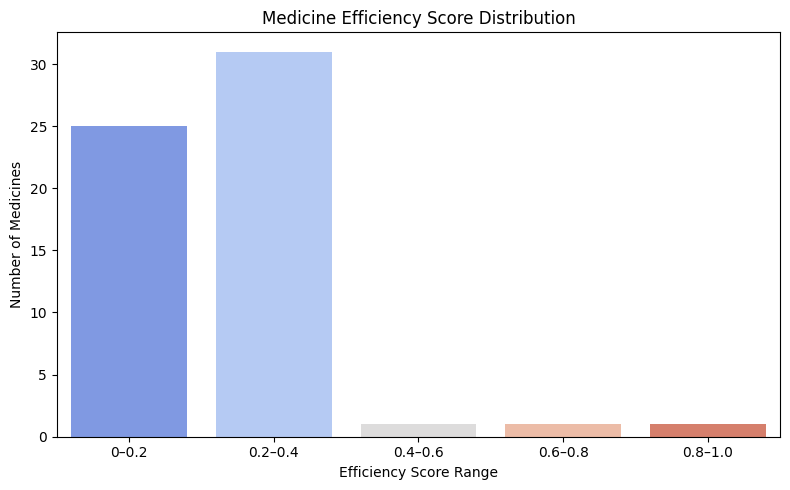

In [ ]:
df_grouped['eff_bin'] = pd.cut(df_grouped['efficiency_score'],
                               bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                               labels=['0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0'])

plt.figure(figsize=(8, 5))
sns.countplot(data=df_grouped, x='eff_bin', palette='coolwarm')
plt.title("Medicine Efficiency Score Distribution")
plt.xlabel("Efficiency Score Range")
plt.ylabel("Number of Medicines")
plt.tight_layout()
plt.show()

# **RFM (Recency, Frequency, Monetary) analysis**

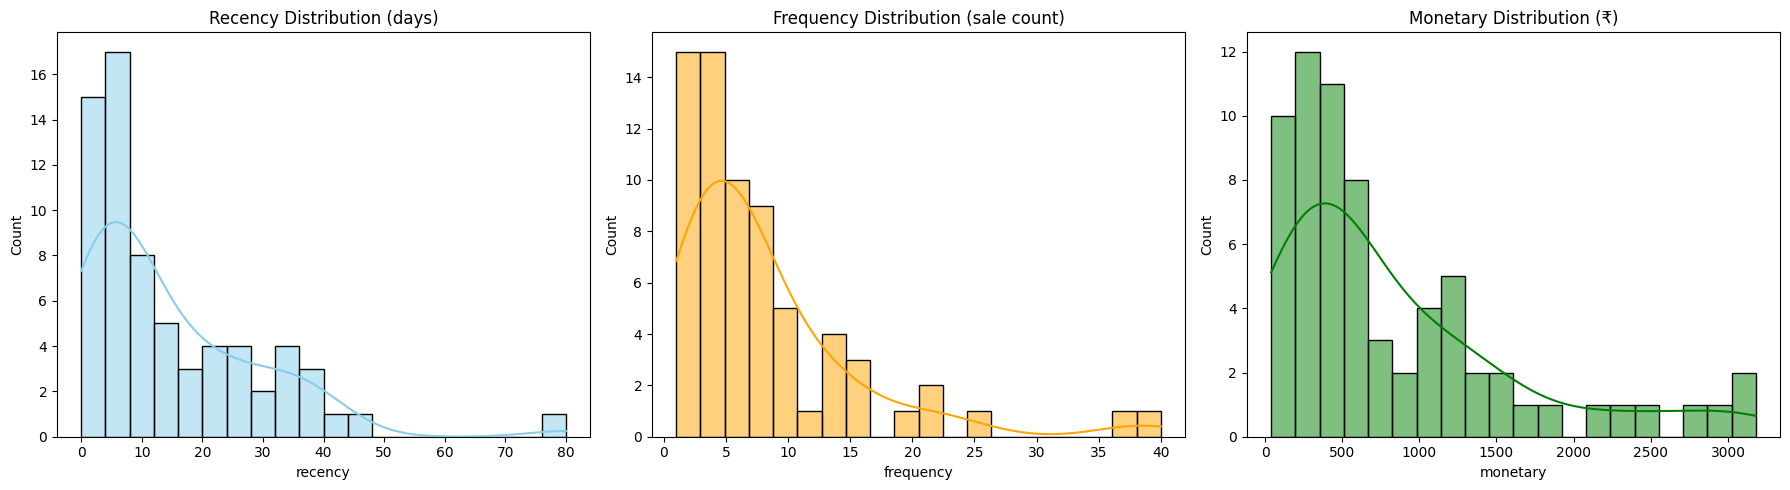

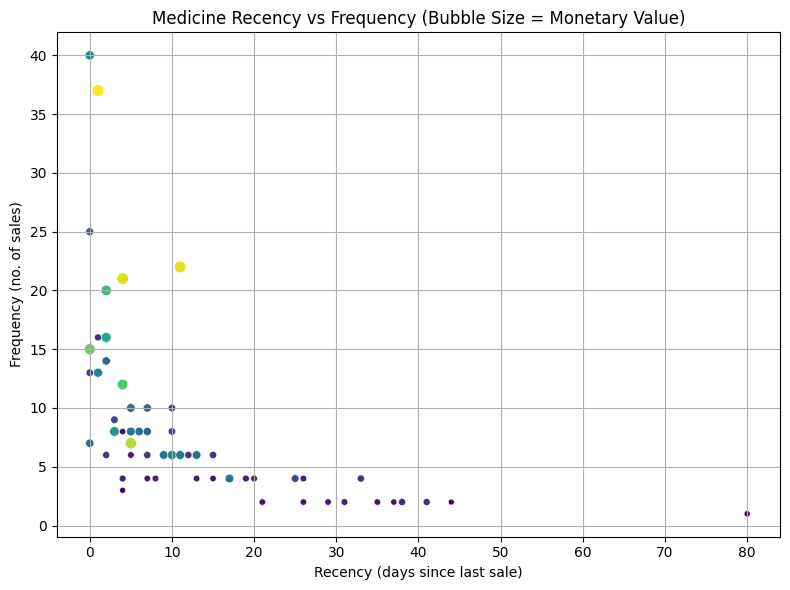

In [ ]:
# Convert 'date' to datetime if not already
df_sales['date'] = pd.to_datetime(df_sales['date'])

# Define a reference date (e.g., today or latest sale date)
reference_date = df_sales['date'].max()

# RFM Calculation
rfm = df_sales.groupby('medicine name').agg({
    'date': lambda x: (reference_date - x.max()).days,   # Recency
    'sold quantity': 'count',                            # Frequency
    'total sales amount': 'sum'                          # Monetary
}).reset_index()

rfm.columns = ['medicine name', 'recency', 'frequency', 'monetary']

# Optional: Normalize RFM for visualization
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
rfm_scaled = rfm.copy()
rfm_scaled[['recency', 'frequency', 'monetary']] = scaler.fit_transform(rfm[['recency', 'frequency', 'monetary']])
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['recency'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Recency Distribution (days)')

sns.histplot(rfm['frequency'], bins=20, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Frequency Distribution (sale count)')

sns.histplot(rfm['monetary'], bins=20, kde=True, ax=axes[2], color='green')
axes[2].set_title('Monetary Distribution (₹)')

plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 6))
sns.scatterplot(data=rfm, x='recency', y='frequency', size='monetary', hue='monetary', palette='viridis', legend=False)
plt.title("Medicine Recency vs Frequency (Bubble Size = Monetary Value)")
plt.xlabel("Recency (days since last sale)")
plt.ylabel("Frequency (no. of sales)")
plt.grid(True)
plt.tight_layout()
plt.show()

